# Fourier Neural Operator demo: 1D Poisson equation

This notebook is designed as a teaching example for a first from-scratch implementation of an FNO.

We learn the operator

- input: forcing field $f(x)$
- output: solution field $u(x)$

for the 1D Poisson problem

$$u_{xx}(x)=f(x),\quad x\in(0,1),\quad u(0)=u(1)=0.$$

To keep the notebook focused on operator learning rather than PDE numerics, we generate synthetic data with an exact sine-series solution. That makes the data pipeline simple and transparent.


In [1]:
config = {
    'n_train': 512,
    'n_test': 128,
    'n_grid': 128,
    'n_sine': 12,
    'coeff_decay': 1.5,
    'batch_size': 32,
    'epochs': 30,
    'learning_rate': 3e-3,
    'weight_decay': 1e-6,
    'modes': 16,
    'width': 48,
    'n_layers': 4,
    'use_w': True,
    'seed': 7,
}

## 1. Imports and setup

In [2]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# For small classroom examples, single-threaded CPU execution is often more stable.
# Comment this out if you want PyTorch to use more CPU threads.
torch.set_num_threads(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

seed = config['seed']
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


Using device: cpu


## 2. Generate an exact supervised dataset

We sample forcing functions in a sine basis,

$$f(x)=\sum_{k=1}^{K} c_k\sin(k\pi x),$$

and then use the exact Dirichlet solution

$$u(x)=-\sum_{k=1}^{K} \frac{c_k}{(k\pi)^2}\sin(k\pi x).$$

That gives us a clean operator-learning dataset without calling a numerical solver.


In [3]:
def make_poisson_dataset(n_samples, n_grid, n_sine=12, coeff_decay=1.5):
    x = torch.linspace(0.0, 1.0, n_grid)
    ks = torch.arange(1, n_sine + 1, dtype=torch.float32)

    # basis[j, k] = sin(k pi x_j)
    basis = torch.sin(math.pi * x[:, None] * ks[None, :])  # [N, K]

    coeffs = torch.randn(n_samples, n_sine) / (ks[None, :] ** coeff_decay)
    f = coeffs @ basis.T
    u = -(coeffs / ((math.pi * ks)[None, :] ** 2)) @ basis.T

    return f.unsqueeze(-1).float(), u.unsqueeze(-1).float(), x.float()

f_train, u_train, x_grid = make_poisson_dataset(
    config['n_train'], config['n_grid'], config['n_sine'], config['coeff_decay']
)
f_test, u_test, _ = make_poisson_dataset(
    config['n_test'], config['n_grid'], config['n_sine'], config['coeff_decay']
)

print('f_train:', tuple(f_train.shape))
print('u_train:', tuple(u_train.shape))


f_train: (512, 128, 1)
u_train: (512, 128, 1)


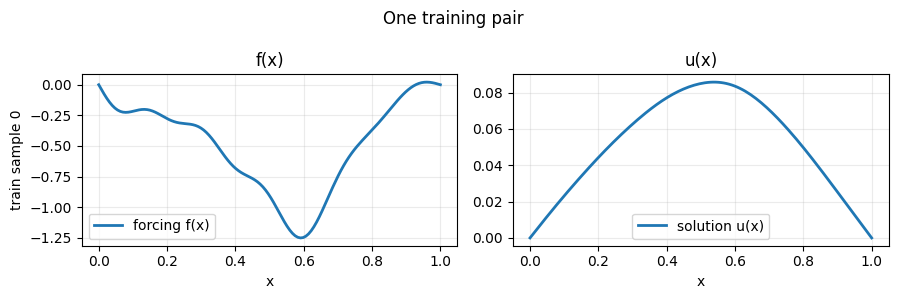

In [4]:
idx = 0
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharex=True)

axes[0].plot(x_grid.numpy(), f_train[idx, :, 0].numpy(), label='forcing f(x)', linewidth=2)
axes[1].plot(x_grid.numpy(), u_train[idx, :, 0].numpy(), label='solution u(x)', linewidth=2)

axes[0].set_title('f(x)')
axes[1].set_title('u(x)')
axes[0].set_ylabel(f'train sample {idx}')
axes[0].grid(alpha=0.25)
axes[1].grid(alpha=0.25)
axes[0].legend()
axes[1].legend()
axes[0].set_xlabel('x')
axes[1].set_xlabel('x')

plt.suptitle('One training pair')
plt.tight_layout()
plt.show()


## 3. Normalize data and append coordinates

A very standard FNO input is the physical field plus the coordinate channel.
So here we feed $[f(x), x]$ into the network.


In [5]:
f_mean, f_std = f_train.mean(), f_train.std()
u_mean, u_std = u_train.mean(), u_train.std()

f_train_n = (f_train - f_mean) / f_std
f_test_n = (f_test - f_mean) / f_std
u_train_n = (u_train - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

grid_channel_train = x_grid.view(1, config['n_grid'], 1).repeat(config['n_train'], 1, 1)
grid_channel_test = x_grid.view(1, config['n_grid'], 1).repeat(config['n_test'], 1, 1)

x_train = torch.cat([f_train_n, grid_channel_train], dim=-1)
x_test = torch.cat([f_test_n, grid_channel_test], dim=-1)

y_train = u_train_n
y_test = u_test_n

print('x_train:', tuple(x_train.shape))
print('y_train:', tuple(y_train.shape))


x_train: (512, 128, 2)
y_train: (512, 128, 1)


## 4. Spectral layer implementation

Key shapes for 1D:

- input to spectral layer: $[B, C_{\mathrm{in}}, N]$
- after $\mathrm{rfft}$: $[B, C_{\mathrm{in}}, \lfloor N/2 \rfloor + 1]$
- retain only the first $m$ low frequencies
- learned complex weights: $[C_{\mathrm{in}}, C_{\mathrm{out}}, m]$
- output after $\mathrm{irfft}$: $[B, C_{\mathrm{out}}, N]$


In [6]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / (in_channels * out_channels)
        self.weights = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )

    def forward(self, x):
        # x: [B, C_in, N]
        B, _, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)  # [B, C_in, N//2 + 1]

        out_ft = torch.zeros(
            B, self.out_channels, x_ft.size(-1),
            device=x.device, dtype=torch.cfloat
        )

        m = min(self.modes, x_ft.size(-1))
        out_ft[:, :, :m] = torch.einsum(
            'bim,iom->bom', x_ft[:, :, :m], self.weights[:, :, :m]
        )

        x = torch.fft.irfft(out_ft, n=N, dim=-1)
        return x


## 5. Full FNO1d model

We use:

- pointwise linear lift
- $n_{\text{layers}}$ Fourier blocks
- each block = spectral branch + pointwise $\mathrm{Conv1d}(1\times1)$ branch + GELU
- pointwise projection back to one output channel


In [7]:
class FNO1d(nn.Module):
    def __init__(self, modes=16, width=48, in_channels=2, out_channels=1, n_layers=4, use_w=True):
        super().__init__()
        self.fc0 = nn.Linear(in_channels, width)
        self.spec_convs = nn.ModuleList(
            [SpectralConv1d(width, width, modes) for _ in range(n_layers)]
        )
        self.ws = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, 64)
        self.fc2 = nn.Linear(64, out_channels)
        self.act = nn.GELU()
        self.use_w = use_w

    def forward(self, x):
        # x: [B, N, in_channels]
        x = self.fc0(x)         # [B, N, width]
        x = x.permute(0, 2, 1)  # [B, width, N]

        for spec, w in zip(self.spec_convs, self.ws):
            if self.use_w:
                x = self.act(spec(x) + w(x))
            else:
                x = self.act(spec(x))

        x = x.permute(0, 2, 1)  # [B, N, width]
        x = self.act(self.fc1(x))
        x = self.fc2(x)         # [B, N, 1]
        return x

model = FNO1d(
    modes=config['modes'],
    width=config['width'],
    in_channels=2,
    out_channels=1,
    n_layers=config['n_layers'],
    use_w=config['use_w'],
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters:', num_params)
print('Using w branch:', model.use_w)


Number of parameters: 160209
Using w branch: True


## 6. Training utilities

In [8]:
def relative_l2(pred, target, eps=1e-12):
    pred = pred.squeeze(-1)
    target = target.squeeze(-1)
    num = torch.linalg.vector_norm(pred - target, dim=1)
    den = torch.linalg.vector_norm(target, dim=1) + eps
    return (num / den).mean()

train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=config['batch_size'],
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(x_test, y_test),
    batch_size=config['batch_size'],
    shuffle=False,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)


## 7. Train

For a CPU run, 20-30 epochs is usually enough to demonstrate that the operator is learning.
If you have a GPU, you can increase `n_train`, `width`, and `epochs`.


In [9]:
history = {'train_mse': [], 'test_rel_l2': []}

for epoch in range(config['epochs']):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = torch.mean((pred - yb) ** 2)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)

    scheduler.step()
    train_loss /= len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        rel_errors = []
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)

            # de-normalize before reporting relative field error
            pred_phys = pred * u_std.to(device) + u_mean.to(device)
            yb_phys = yb * u_std.to(device) + u_mean.to(device)
            rel_errors.append(relative_l2(pred_phys, yb_phys).item())

    test_rel = float(np.mean(rel_errors))
    history['train_mse'].append(train_loss)
    history['test_rel_l2'].append(test_rel)

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d} | train MSE = {train_loss:.6f} | test rel L2 = {test_rel:.6f}')


Epoch   1 | train MSE = 0.492213 | test rel L2 = 0.796242
Epoch   5 | train MSE = 0.003677 | test rel L2 = 0.087693
Epoch  10 | train MSE = 0.000593 | test rel L2 = 0.046666
Epoch  15 | train MSE = 0.000264 | test rel L2 = 0.021370
Epoch  20 | train MSE = 0.000075 | test rel L2 = 0.014141
Epoch  25 | train MSE = 0.000059 | test rel L2 = 0.013429
Epoch  30 | train MSE = 0.000085 | test rel L2 = 0.012398


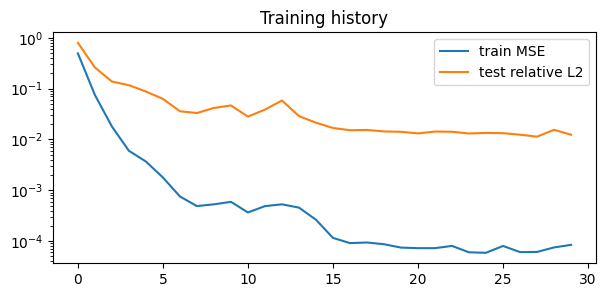

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history['train_mse'], label='train MSE')
ax.plot(history['test_rel_l2'], label='test relative L2')
ax.set_yscale('log')
ax.set_title('Training history')
ax.legend()
plt.show()


## 8. Inspect predictions

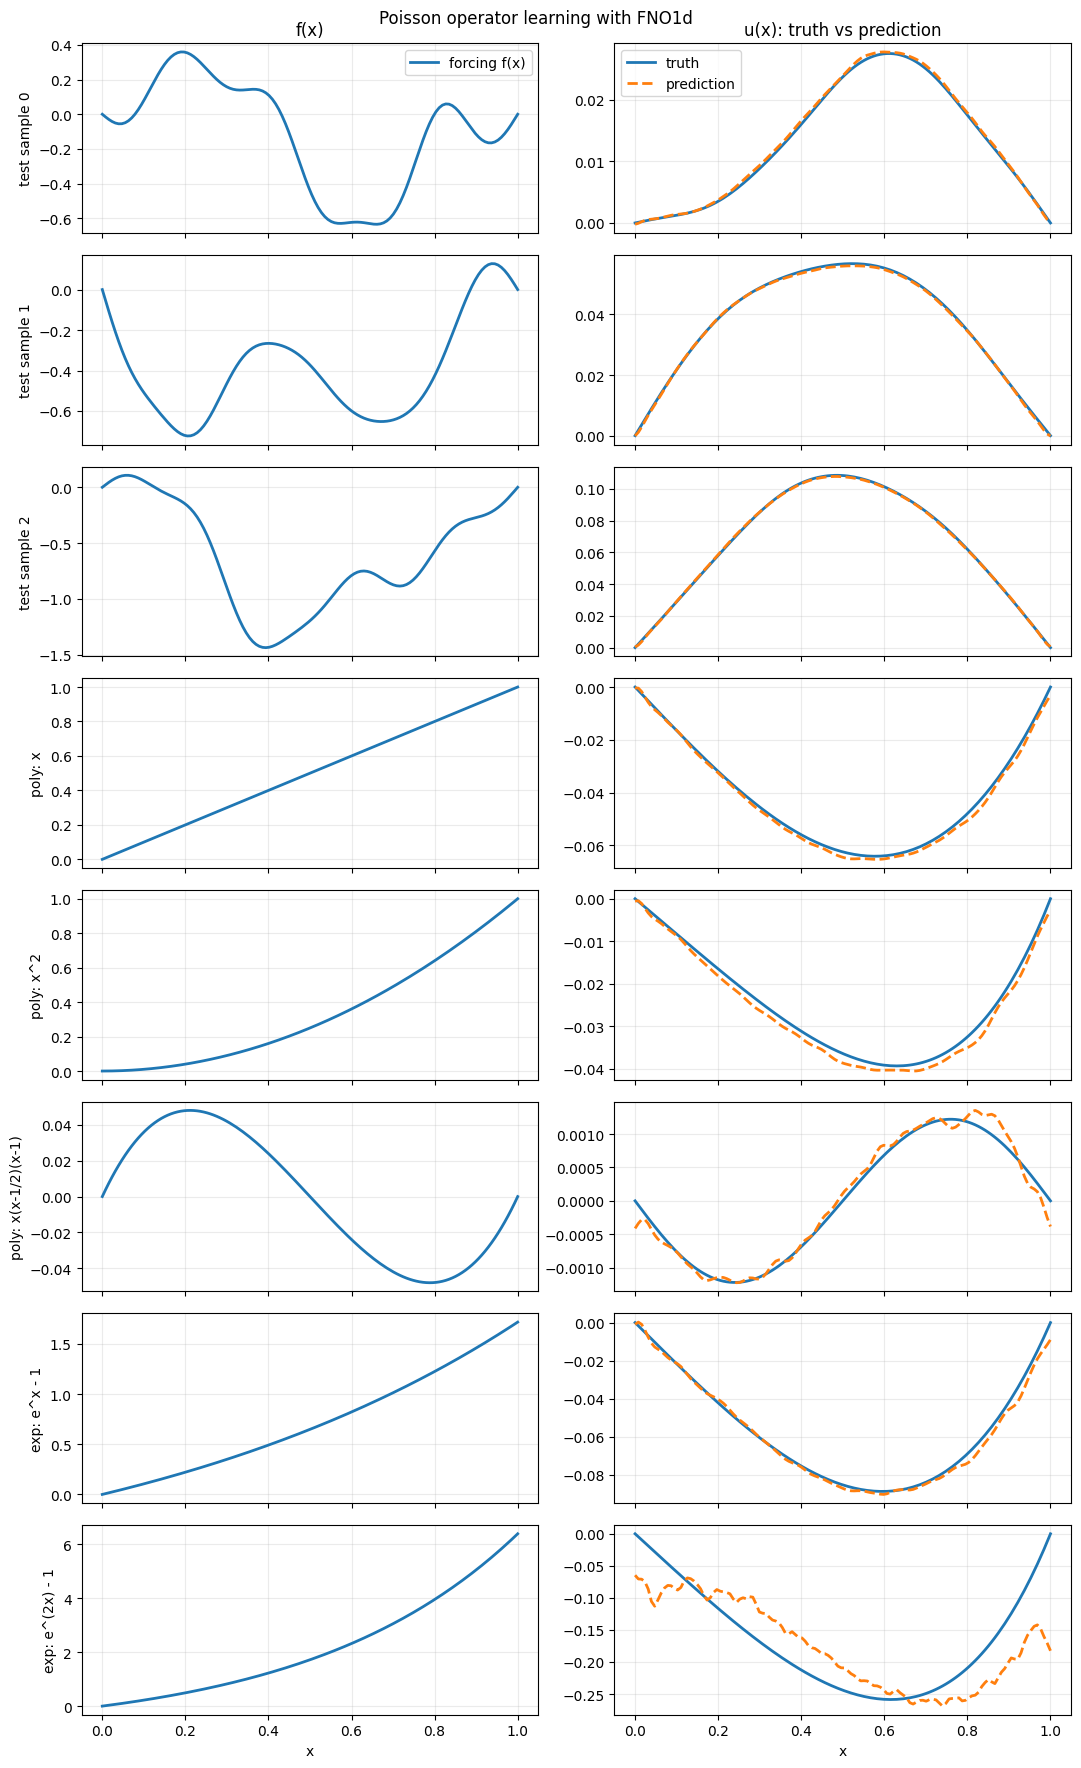

In [11]:
def solve_poisson_dirichlet_fd(f_vals, x):
    n = x.numel()
    h = float(x[1] - x[0])

    main = torch.full((n - 2,), -2.0 / (h * h), dtype=f_vals.dtype)
    off = torch.full((n - 3,), 1.0 / (h * h), dtype=f_vals.dtype)
    a = torch.diag(main) + torch.diag(off, diagonal=1) + torch.diag(off, diagonal=-1)

    u = torch.zeros_like(f_vals)
    u[1:-1] = torch.linalg.solve(a, f_vals[1:-1])
    return u


x = x_grid
example_names = []
f_examples = []
u_true_examples = []

# In-distribution test examples
for idx in [0, 1, 2]:
    example_names.append(f'test sample {idx}')
    f_examples.append(f_test[idx, :, 0])
    u_true_examples.append(u_test[idx, :, 0])

# Out-of-distribution forcing examples (non-sine-series forms)
ood_forcings = [
    ('poly: x', x),
    ('poly: x^2', x**2),
    ('poly: x(x-1/2)(x-1)', x * (x - 0.5) * (x - 1.0)),
    ('exp: e^x - 1', torch.exp(x) - 1.0),
    ('exp: e^(2x) - 1', torch.exp(2 * x) - 1.0),
]

for name, f_vals in ood_forcings:
    example_names.append(name)
    f_examples.append(f_vals)
    u_true_examples.append(solve_poisson_dirichlet_fd(f_vals, x))

f_examples = torch.stack(f_examples, dim=0).unsqueeze(-1)
u_true_examples = torch.stack(u_true_examples, dim=0).unsqueeze(-1)

f_examples_n = (f_examples - f_mean) / f_std
grid_channel = x.view(1, -1, 1).repeat(f_examples.shape[0], 1, 1)
x_examples = torch.cat([f_examples_n, grid_channel], dim=-1)

model.eval()
with torch.no_grad():
    pred_examples = model(x_examples.to(device)).cpu()

pred_examples = pred_examples * u_std + u_mean

fig, axes = plt.subplots(len(example_names), 2, figsize=(11, 2.25 * len(example_names)), sharex=True)
if len(example_names) == 1:
    axes = axes[None, :]

for row, name in enumerate(example_names):
    ax_f = axes[row, 0]
    ax_u = axes[row, 1]

    ax_f.plot(x.numpy(), f_examples[row, :, 0].numpy(), label='forcing f(x)', linewidth=2)
    ax_u.plot(x.numpy(), u_true_examples[row, :, 0].numpy(), label='truth', linewidth=2)
    ax_u.plot(x.numpy(), pred_examples[row, :, 0].numpy(), '--', label='prediction', linewidth=2)

    ax_f.set_ylabel(name)
    ax_f.grid(alpha=0.25)
    ax_u.grid(alpha=0.25)

axes[0, 0].set_title('f(x)')
axes[0, 1].set_title('u(x): truth vs prediction')
axes[0, 0].legend()
axes[0, 1].legend()
axes[-1, 0].set_xlabel('x')
axes[-1, 1].set_xlabel('x')
plt.suptitle('Poisson operator learning with FNO1d')
plt.tight_layout()
plt.show()
